# CustomerIQ - Day 5: Predictive Modeling

This notebook builds an interpretable logistic regression baseline for predicting `observed_churn`. The customer-level dataset contains 3,705 eligible customers. Features describe transactions before 2011-09-10, while the target comes from the separate 90-day validation window ending 2011-12-09.

This is a Day 5 baseline, not a production-ready model. No future information, `returned_in_validation`, customer identifier, or raw purchase dates will be used as predictors.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
FEATURES = [
    'Frequency',
    'Monetary',
    'Recency',
    'Customer Lifespan',
    'Average Purchase Interval',
    'Median Purchase Interval',
]
TARGET = 'observed_churn'
input_path = Path('../Data/Processed/customer_churn_analysis.csv')
output_path = Path('../Data/Processed/logistic_regression_predictions.csv')

## 1. Load and Validate the Customer-Level Dataset

In [2]:
customers = pd.read_csv(input_path)

print(f'Shape: {customers.shape}')
print('Columns:', list(customers.columns))
print('\nMissing values:')
print(customers.isna().sum())
print(f'\nDuplicate Customer IDs: {customers["Customer ID"].duplicated().sum()}')
print('\nTarget distribution:')
print(customers[TARGET].value_counts().sort_index())
print('\nTarget proportions:')
print(customers[TARGET].value_counts(normalize=True).sort_index())

required_columns = FEATURES + ['Customer ID', TARGET, 'returned_in_validation']
assert customers.shape[0] == 3705
assert set(required_columns).issubset(customers.columns)
assert customers['Customer ID'].is_unique
assert customers[FEATURES + [TARGET]].notna().all().all()
assert customers[TARGET].isin([0, 1]).all()
assert customers['returned_in_validation'].isin([0, 1]).all()
print('\nValidation checks passed.')

Shape: (3705, 11)
Columns: ['Customer ID', 'Frequency', 'Monetary', 'First Purchase Date', 'Last Purchase Date', 'Customer Lifespan', 'Recency', 'Average Purchase Interval', 'Median Purchase Interval', 'returned_in_validation', 'observed_churn']

Missing values:
Customer ID                  0
Frequency                    0
Monetary                     0
First Purchase Date          0
Last Purchase Date           0
Customer Lifespan            0
Recency                      0
Average Purchase Interval    0
Median Purchase Interval     0
returned_in_validation       0
observed_churn               0
dtype: int64

Duplicate Customer IDs: 0

Target distribution:
observed_churn
0    1973
1    1732
Name: count, dtype: int64

Target proportions:
observed_churn
0    0.532524
1    0.467476
Name: proportion, dtype: float64

Validation checks passed.


## 2. Define Predictors and Target

Only the six pre-cutoff behavioral features are included. `returned_in_validation` directly reveals the target and is excluded as leakage. `Customer ID` and purchase dates are identifiers or raw dates, so they are also excluded.

In [3]:
X = customers[FEATURES].copy()
y = customers[TARGET].copy()

print(f'Predictor matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')
print('Predictors:', FEATURES)

Predictor matrix shape: (3705, 6)
Target shape: (3705,)
Predictors: ['Frequency', 'Monetary', 'Recency', 'Customer Lifespan', 'Average Purchase Interval', 'Median Purchase Interval']


## 3. Stratified Train/Test Split

Stratification preserves the observed-churn proportion in both subsets. The fixed seed makes the split reproducible.

In [4]:
X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X,
    y,
    customers['Customer ID'],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Train rows: {len(X_train)}')
print(f'Test rows: {len(X_test)}')
print(f'Train churn rate: {y_train.mean():.4f}')
print(f'Test churn rate: {y_test.mean():.4f}')

Train rows: 2964
Test rows: 741
Train churn rate: 0.4676
Test churn rate: 0.4669


## 4. Leakage-Safe Logistic Regression Pipeline

`StandardScaler` is inside the `Pipeline`, so its parameters are learned from training data only. Logistic Regression provides a transparent coefficient for each standardized feature.

In [5]:
preprocessor = ColumnTransformer(
    transformers=[('scale', StandardScaler(), FEATURES)],
    remainder='drop',
)

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ]
)

model.fit(X_train, y_train)
predicted_churn = model.predict(X_test)
churn_probability = model.predict_proba(X_test)[:, 1]
print('Model trained and test predictions generated.')

Model trained and test predictions generated.


## 5. Evaluate the Baseline Model

In [6]:
accuracy = accuracy_score(y_test, predicted_churn)
precision = precision_score(y_test, predicted_churn, zero_division=0)
recall = recall_score(y_test, predicted_churn, zero_division=0)
f1 = f1_score(y_test, predicted_churn, zero_division=0)
roc_auc = roc_auc_score(y_test, churn_probability)
confusion = confusion_matrix(y_test, predicted_churn)

metrics = pd.Series({
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'ROC-AUC': roc_auc,
})
print(metrics.to_string(float_format=lambda value: f'{value:.4f}'))
print('\nConfusion Matrix:')
print(confusion)
print('\nClassification Report:')
print(classification_report(y_test, predicted_churn, target_names=['No observed churn', 'Observed churn'], zero_division=0))

Accuracy    0.7045
Precision   0.7068
Recall      0.6272
F1 Score    0.6646
ROC-AUC     0.7731

Confusion Matrix:
[[305  90]
 [129 217]]

Classification Report:
                   precision    recall  f1-score   support

No observed churn       0.70      0.77      0.74       395
   Observed churn       0.71      0.63      0.66       346

         accuracy                           0.70       741
        macro avg       0.70      0.70      0.70       741
     weighted avg       0.70      0.70      0.70       741



## 6. Model Visualizations

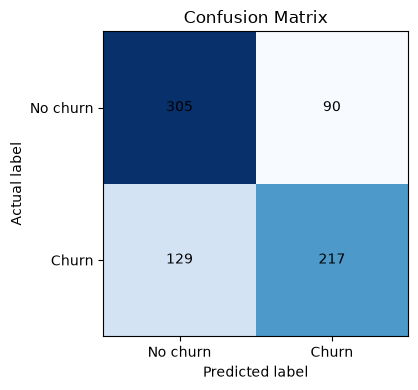

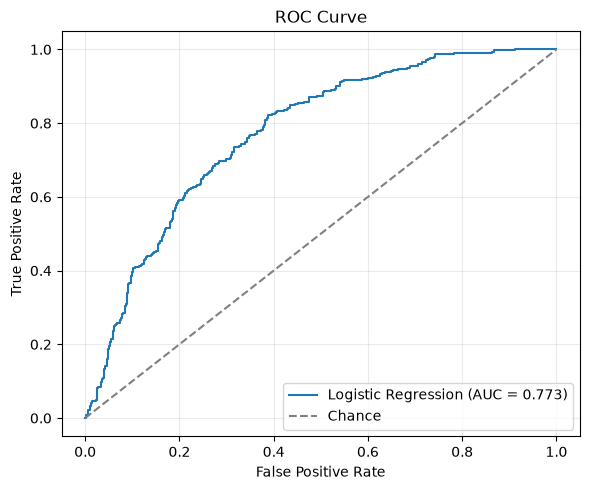

In [7]:
fig, axis = plt.subplots(figsize=(5, 4))
axis.imshow(confusion, cmap='Blues')
axis.set_title('Confusion Matrix')
axis.set_xlabel('Predicted label')
axis.set_ylabel('Actual label')
axis.set_xticks([0, 1], ['No churn', 'Churn'])
axis.set_yticks([0, 1], ['No churn', 'Churn'])
for row in range(2):
    for column in range(2):
        axis.text(column, row, confusion[row, column], ha='center', va='center')
fig.tight_layout()
plt.show()

false_positive_rate, true_positive_rate, _ = roc_curve(y_test, churn_probability)
fig, axis = plt.subplots(figsize=(6, 5))
axis.plot(false_positive_rate, true_positive_rate, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
axis.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Chance')
axis.set_title('ROC Curve')
axis.set_xlabel('False Positive Rate')
axis.set_ylabel('True Positive Rate')
axis.legend()
axis.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 7. Interpret Logistic Regression Coefficients

Because predictors are standardized, coefficients compare the association of a one-standard-deviation feature increase with predicted churn risk. A positive coefficient means increased predicted churn risk; a negative coefficient means decreased predicted churn risk. Odds Ratio is `exp(Coefficient)`.

,Feature,Coefficient,Odds Ratio,Direction
0,Average Purchase Interval,0.828583,2.290072,Increased predicted churn risk
1,Recency,0.701696,2.017171,Increased predicted churn risk
2,Monetary,-0.041235,0.959604,Decreased predicted churn risk
3,Customer Lifespan,-0.264966,0.767232,Decreased predicted churn risk
4,Frequency,-0.383529,0.681452,Decreased predicted churn risk
5,Median Purchase Interval,-0.405152,0.666876,Decreased predicted churn risk


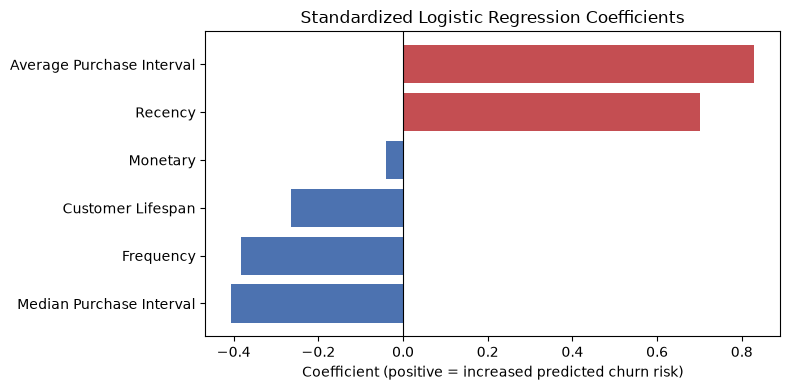

In [8]:
classifier = model.named_steps['classifier']
coefficients = classifier.coef_[0]
coefficient_table = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': coefficients,
})
coefficient_table['Odds Ratio'] = coefficient_table['Coefficient'].map(lambda value: __import__('math').exp(value))
coefficient_table['Direction'] = coefficient_table['Coefficient'].map(
    lambda value: 'Increased predicted churn risk' if value > 0 else 'Decreased predicted churn risk'
)
coefficient_table = coefficient_table.sort_values('Coefficient', ascending=False).reset_index(drop=True)
display(coefficient_table)

fig, axis = plt.subplots(figsize=(8, 4))
ordered = coefficient_table.sort_values('Coefficient')
colors = ['#c44e52' if value > 0 else '#4c72b0' for value in ordered['Coefficient']]
axis.barh(ordered['Feature'], ordered['Coefficient'], color=colors)
axis.axvline(0, color='black', linewidth=0.8)
axis.set_title('Standardized Logistic Regression Coefficients')
axis.set_xlabel('Coefficient (positive = increased predicted churn risk)')
fig.tight_layout()
plt.show()

## 8. Save Test-Set Predictions

The export contains only held-out test customers and the requested actual, predicted, and probability fields.

In [9]:
predictions = pd.DataFrame({
    'Customer ID': ids_test.to_numpy(),
    'actual observed_churn': y_test.to_numpy(),
    'predicted_churn': predicted_churn,
    'churn_probability': churn_probability,
})
predictions.to_csv(output_path, index=False)

assert output_path.exists()
saved_predictions = pd.read_csv(output_path)
assert list(saved_predictions.columns) == [
    'Customer ID', 'actual observed_churn', 'predicted_churn', 'churn_probability'
]
assert len(saved_predictions) == len(X_test)
print(f'Saved: {output_path}')
print(f'Prediction rows: {len(saved_predictions)}')

Saved: ..\Data\Processed\logistic_regression_predictions.csv
Prediction rows: 741


## 9. Day 5 Execution Report

This concise report records the reproducible baseline results. The strongest positive coefficient is the feature most associated with increased predicted churn risk in this fitted baseline; the strongest negative coefficient is most associated with decreased predicted churn risk. These are associations, not causal conclusions.

In [10]:
strongest_positive = coefficient_table.loc[coefficient_table['Coefficient'].idxmax()]
strongest_negative = coefficient_table.loc[coefficient_table['Coefficient'].idxmin()]
target_counts = y.value_counts().sort_index().to_dict()

print('DAY 5 BASELINE EXECUTION REPORT')
print(f'Train/test sizes: {len(X_train)} / {len(X_test)}')
print(f'Target distribution (0=no observed churn, 1=observed churn): {target_counts}')
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1: {f1:.4f}')
print(f'ROC-AUC: {roc_auc:.4f}')
print(f'Strongest positive churn coefficient: {strongest_positive["Feature"]} ({strongest_positive["Coefficient"]:.4f})')
print(f'Strongest negative churn coefficient: {strongest_negative["Feature"]} ({strongest_negative["Coefficient"]:.4f})')
print('Source CSV modified: No')
print('Baseline status: Day 5 interpretable logistic regression; not production-ready.')

DAY 5 BASELINE EXECUTION REPORT
Train/test sizes: 2964 / 741
Target distribution (0=no observed churn, 1=observed churn): {0: 1973, 1: 1732}
Accuracy: 0.7045
Precision: 0.7068
Recall: 0.6272
F1: 0.6646
ROC-AUC: 0.7731
Strongest positive churn coefficient: Average Purchase Interval (0.8286)
Strongest negative churn coefficient: Median Purchase Interval (-0.4052)
Source CSV modified: No
Baseline status: Day 5 interpretable logistic regression; not production-ready.
